# Baseline Models

### Setup


In [2]:
from pathlib import Path
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
    precision_recall_fscore_support,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore", category=ConvergenceWarning)

ROOT = Path.cwd().resolve()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

CONFIG = json.loads(
    (ROOT / "config/project_config.json").read_text(encoding="utf-8")
)
LABELS = CONFIG["bin_labels"]
CLASSES = np.arange(len(LABELS))
PRIMARY_HORIZON = int(CONFIG["primary_horizon"])
START_DATE = pd.Timestamp(CONFIG["start_date"])
VALIDATION_START_DATE = pd.Timestamp(CONFIG["validation_start_date"])
TEST_START_DATE = pd.Timestamp(CONFIG["test_start_date"])

data = pd.read_parquet(
    ROOT / f"data/modeling/sfo_delay_features_{PRIMARY_HORIZON}h.parquet"
)
data = data.loc[data["target_delay_bin"].notna()]


### Temporal split

Use the same project split throughout the modeling notebooks.

In [3]:
train = data.loc[data["flight_date"] < VALIDATION_START_DATE].copy()
validation = data.loc[
    (data["flight_date"] >= VALIDATION_START_DATE)
    & (data["flight_date"] < TEST_START_DATE)
].copy()
test = data.loc[data["flight_date"] >= TEST_START_DATE].copy()

splits = {
    "Train": train,
    "Validation": validation,
    "Test": test,
}

split_summary = pd.DataFrame(
    {
        "split": list(splits.keys()),
        "rows": [len(frame) for frame in splits.values()],
        "start_date": [
            frame["flight_date"].min().date()
            for frame in splits.values()
        ],
        "end_date": [
            frame["flight_date"].max().date()
            for frame in splits.values()
        ],
    }
)
display(split_summary)

,split,rows,start_date,end_date
0,Train,293770,2022-01-01,2024-12-31
1,Validation,109971,2025-01-01,2025-12-31
2,Test,45646,2026-01-01,2026-05-31


### Class distribution

The bins are unequal because most flights depart within 15 minutes of schedule. Accuracy therefore needs to be read together with macro-F1 and balanced accuracy.


,Train,Validation,Test
target_delay_bin_label,,,
under_15,78.85,80.82,77.38
15_to_under_60,14.15,12.36,14.77
60_to_under_120,4.4,4.16,5.07
120_to_under_240,1.96,2.0,2.14
240_plus,0.64,0.66,0.65


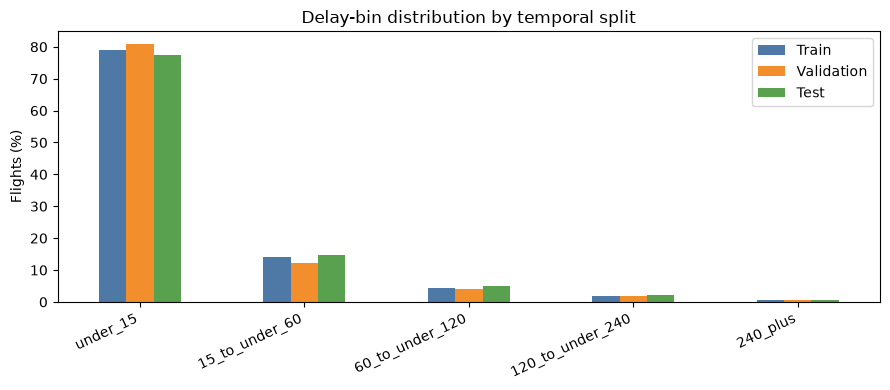

In [4]:
class_balance = pd.DataFrame(
    {
        name: 100
        * frame["target_delay_bin_label"].value_counts(normalize=True)
        for name, frame in splits.items()
    }
).reindex(LABELS)

display(class_balance.round(2))

class_balance.plot.bar(figsize=(9, 4), color=["#4E79A7", "#F28E2B", "#59A14F"])
plt.ylabel("Flights (%)")
plt.xlabel("")
plt.title("Delay-bin distribution by temporal split")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


### Schedule-only features

These are the baseline inputs: carrier, destination, time-of-day, calendar, and scheduled traffic. No current-flight realized delay information is used.

In [5]:
SCHEDULE_FEATURES = [
    "reporting_airline", "dest", "day_of_week", "scheduled_dep_hour",
    "scheduled_arr_hour", "month", "is_weekend", "hour_sin", "hour_cos",
    "month_sin", "month_cos", "days_until_holiday", "days_since_holiday",
    "scheduled_sfo_departures_same_hour",
    "scheduled_carrier_departures_same_hour",
    "distance_miles", "scheduled_elapsed_minutes",
]
CATEGORICAL_FEATURES = ["reporting_airline", "dest"]
NUMERIC_FEATURES = [
    feature
    for feature in SCHEDULE_FEATURES
    if feature not in CATEGORICAL_FEATURES
]

display(pd.DataFrame({"schedule_feature": SCHEDULE_FEATURES}))


,schedule_feature
0,reporting_airline
1,dest
2,day_of_week
3,scheduled_dep_hour
4,scheduled_arr_hour
5,month
6,is_weekend
7,hour_sin
8,hour_cos
9,month_sin


### Preprocessing and logistic regression

Missing numeric values use the training median. Airline and destination use the most frequent training value before one-hot encoding.

In [6]:
def prepare_schedule_data(frame):
    model_data = frame[SCHEDULE_FEATURES].copy()

    model_data[NUMERIC_FEATURES] = model_data[NUMERIC_FEATURES].apply(
        pd.to_numeric,
        errors="coerce",
    )
    for column in CATEGORICAL_FEATURES:
        model_data[column] = model_data[column].astype(object).where(
            model_data[column].notna(),
            np.nan,
        )
    return model_data


def build_schedule_model():
    numeric_pipeline = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ]
    )
    categorical_pipeline = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="infrequent_if_exist",
                    min_frequency=25,
                ),
            ),
        ]
    )
    preprocessing = ColumnTransformer(
        [
            ("numeric", numeric_pipeline, NUMERIC_FEATURES),
            ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
        ]
    )
    logistic = LogisticRegression(
        max_iter=600,
        solver="lbfgs",
        random_state=CONFIG["seed"],
    )
    return Pipeline(
        [
            ("preprocessing", preprocessing),
            ("model", logistic),
        ]
    )

### Light class weighting

The bins are imbalanced, so we use square-root balanced weights. This helps rare bins without making the baseline chase every rare example.

In [7]:
def make_sample_weights(y):
    balanced = compute_class_weight(
        "balanced",
        classes=CLASSES,
        y=y,
    )
    return np.sqrt(balanced)[y]


y_train = train["target_delay_bin"].astype(int).to_numpy()
class_weight_table = pd.DataFrame(
    {
        "delay_bin": LABELS,
        "sqrt_class_weight": np.sqrt(
            compute_class_weight("balanced", classes=CLASSES, y=y_train)
        ),
    }
).set_index("delay_bin")

display(class_weight_table.round(3))


,sqrt_class_weight
delay_bin,
under_15,0.504
15_to_under_60,1.189
60_to_under_120,2.132
120_to_under_240,3.196
240_plus,5.584


### Evaluation functions

The main report uses accuracy, macro F1, log loss, within-one-bin accuracy, and severe delay recall.

In [8]:
def score_predictions(actual, probabilities):
    predicted = probabilities.argmax(axis=1)
    actual_severe = np.isin(actual, [3, 4])
    predicted_severe = np.isin(predicted, [3, 4])

    return {
        "accuracy": accuracy_score(actual, predicted),
        "balanced_accuracy": balanced_accuracy_score(actual, predicted),
        "macro_f1": f1_score(
            actual, predicted, average="macro", zero_division=0
        ),
        "log_loss": log_loss(actual, probabilities, labels=CLASSES),
        "within_one_bin": np.mean(np.abs(actual - predicted) <= 1),
        "severe_recall": recall_score(
            actual_severe, predicted_severe, zero_division=0
        ),
    }


### No-skill reference

This model always assigns probability 1 to `under_15`. It shows how much accuracy is available from class imbalance alone.


In [9]:
no_skill_rows = []
for split_name, frame in splits.items():
    actual = frame["target_delay_bin"].astype(int).to_numpy()
    probabilities = np.zeros((len(frame), len(CLASSES)))
    probabilities[:, 0] = 1

    row = {"split": split_name}
    row.update(score_predictions(actual, probabilities))
    no_skill_rows.append(row)

no_skill_results = pd.DataFrame(no_skill_rows).set_index("split")
display(no_skill_results.round(4))


,accuracy,balanced_accuracy,macro_f1,log_loss,within_one_bin,severe_recall
split,,,,,,
Train,0.7885,0.2,0.1763,7.6237,0.9300,0.0
Validation,0.8082,0.2,0.1788,6.9137,0.9318,0.0
Test,0.7738,0.2,0.1745,8.1538,0.9215,0.0


### Train the baseline and plot log loss

,training_rows,train_log_loss,validation_log_loss,train_accuracy,validation_accuracy
training_window,,,,,
through 2022,91220,0.7787,0.8066,0.8094,0.7961
through 2023,191930,0.8199,0.8229,0.7941,0.7986
through 2024,293770,0.8449,0.8323,0.7791,0.7956


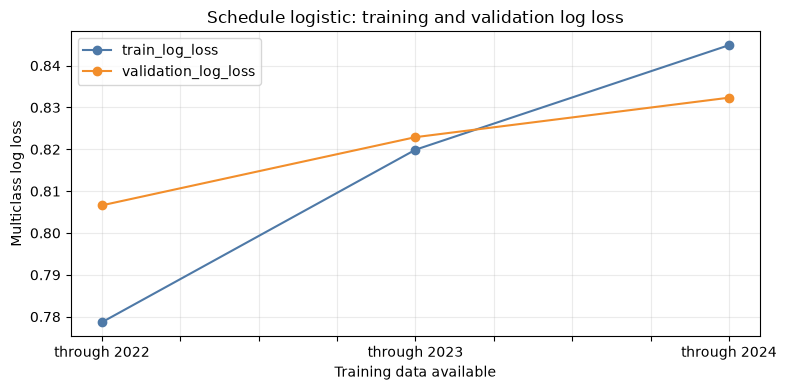

In [10]:
training_windows = [
    (f"through {end_date.year - 1}", end_date)
    for end_date in pd.date_range(
        start=START_DATE + pd.DateOffset(years=1),
        end=VALIDATION_START_DATE,
        freq="YS",
    )
]
learning_rows = []

y_validation = validation["target_delay_bin"].astype(int).to_numpy()

for window_name, end_date in training_windows:
    training_subset = train.loc[train["flight_date"] < end_date]
    y_subset = training_subset["target_delay_bin"].astype(int).to_numpy()

    model = build_schedule_model()
    model.fit(
        prepare_schedule_data(training_subset),
        y_subset,
        model__sample_weight=make_sample_weights(y_subset),
    )
    
    training_probabilities = model.predict_proba(prepare_schedule_data(training_subset))
    validation_probabilities = model.predict_proba(prepare_schedule_data(validation))

    training_scores = score_predictions(y_subset, training_probabilities)
    validation_scores = score_predictions(y_validation, validation_probabilities)

    learning_rows.append(
        {
            "training_window": window_name,
            "training_rows": len(training_subset),
            "train_log_loss": training_scores["log_loss"],
            "validation_log_loss": validation_scores["log_loss"],
            "train_accuracy": training_scores["accuracy"],
            "validation_accuracy": validation_scores["accuracy"],
        }
    )

    if end_date == VALIDATION_START_DATE:
        training_model = model
        training_train_probabilities = training_probabilities
        training_validation_probabilities = validation_probabilities

learning_curve = pd.DataFrame(learning_rows).set_index("training_window")
display(learning_curve.round(4))

learning_curve[["train_log_loss", "validation_log_loss"]].plot(
    marker="o",
    figsize=(8, 4),
    color=["#4E79A7", "#F28E2B"],
)
plt.ylabel("Multiclass log loss")
plt.xlabel("Training data available")
plt.title("Schedule logistic: training and validation log loss")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


### Train-validation gap


In [11]:
training_results = pd.DataFrame(
    [
        {
            "split": "Train",
            **score_predictions(y_train, training_train_probabilities),
        },
        {
            "split": "Validation",
            **score_predictions(
                y_validation,
                training_validation_probabilities,
            ),
        },
    ]
).set_index("split")

validation_gap = pd.DataFrame(
    {
        "value": [
            training_results.loc["Train", "accuracy"] - training_results.loc["Validation", "accuracy"],
            training_results.loc["Validation", "log_loss"] - training_results.loc["Train", "log_loss"],
        ]
    },
    index=[
        "train_minus_validation_accuracy",
        "validation_minus_train_log_loss",
    ],
)

display(training_results.round(4))
display(validation_gap.round(4))

,accuracy,balanced_accuracy,macro_f1,log_loss,within_one_bin,severe_recall
split,,,,,,
Train,0.7791,0.2133,0.2055,0.8449,0.9336,0.0000
Validation,0.7956,0.2154,0.2102,0.8323,0.9351,0.0003


,value
train_minus_validation_accuracy,-0.0165
validation_minus_train_log_loss,-0.0125


### Confusion matrix

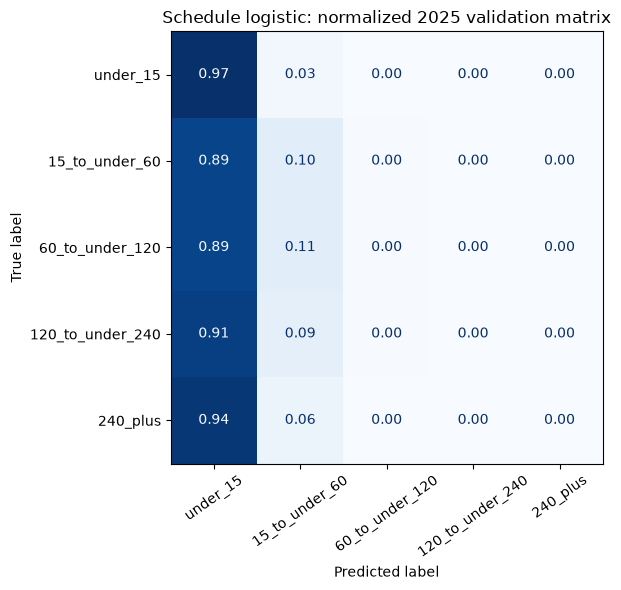

In [12]:
validation_predictions = training_validation_probabilities.argmax(axis=1)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    validation_predictions,
    labels=CLASSES,
    display_labels=LABELS,
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=35,
    colorbar=False,
    ax=ax,
)
ax.set_title("Schedule logistic: normalized 2025 validation matrix")
plt.tight_layout()
plt.show()


### Final baseline test

After checking 2025 validation performance, refit the baseline on 2022-2025 and evaluate once on 2026.

In [13]:
final_train = data.loc[data["flight_date"] < TEST_START_DATE]
y_final_train = final_train["target_delay_bin"].astype(int).to_numpy()
y_test = test["target_delay_bin"].astype(int).to_numpy()

final_model = build_schedule_model()
final_model.fit(
    prepare_schedule_data(final_train),
    y_final_train,
    model__sample_weight=make_sample_weights(y_final_train),
)

final_train_probabilities = final_model.predict_proba(prepare_schedule_data(final_train))
test_probabilities = final_model.predict_proba(prepare_schedule_data(test))

final_rows = []
for split_name, actual, probabilities in [
    ("Train + Validation", y_final_train, final_train_probabilities),
    ("Test", y_test, test_probabilities),
]:
    row = {"split": split_name}
    row.update(score_predictions(actual, probabilities))
    final_rows.append(row)

final_results = pd.DataFrame(final_rows).set_index("split")
train_test_gap = pd.DataFrame(
    {
        "value": [
            final_results.loc["Train + Validation", "accuracy"]
            - final_results.loc["Test", "accuracy"],
            final_results.loc["Test", "log_loss"]
            - final_results.loc["Train + Validation", "log_loss"],
        ]
    },
    index=["train_minus_test_accuracy", "test_minus_train_log_loss"],
)

test_comparison = pd.DataFrame(
    {
        "always_under_15": no_skill_results.loc["Test"],
        "schedule_logistic": final_results.loc["Test"],
    }
).T

display(final_results.round(4))
display(train_test_gap.round(4))
display(test_comparison.round(4))


,accuracy,balanced_accuracy,macro_f1,log_loss,within_one_bin,severe_recall
split,,,,,,
Train + Validation,0.7838,0.2150,0.2083,0.8369,0.9347,0.0001
Test,0.7659,0.2189,0.2124,0.8746,0.9278,0.0000


,value
train_minus_test_accuracy,0.0178
test_minus_train_log_loss,0.0376


,accuracy,balanced_accuracy,macro_f1,log_loss,within_one_bin,severe_recall
always_under_15,0.7738,0.2000,0.1745,8.1538,0.9215,0.0
schedule_logistic,0.7659,0.2189,0.2124,0.8746,0.9278,0.0


### Test confusion matrix and per-bin results


,precision,recall,f1,support
under_15,0.7920,0.9660,0.8704,35320
15_to_under_60,0.3410,0.1231,0.1809,6741
60_to_under_120,0.0977,0.0056,0.0106,2314
120_to_under_240,0.0000,0.0000,0.0000,975
240_plus,0.0000,0.0000,0.0000,296


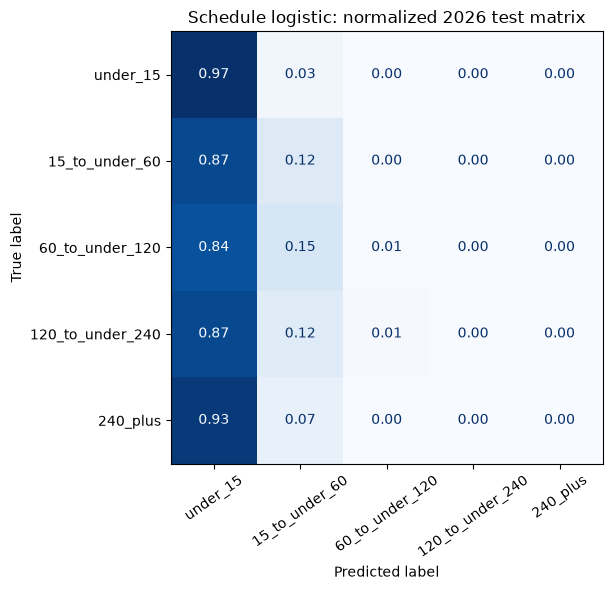

In [14]:
test_predictions = test_probabilities.argmax(axis=1)
precision, recall, f1, support = precision_recall_fscore_support(
    y_test,
    test_predictions,
    labels=CLASSES,
    zero_division=0,
)
per_bin_results = pd.DataFrame(
    {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support,
    },
    index=LABELS,
)
display(per_bin_results.round(4))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    labels=CLASSES,
    display_labels=LABELS,
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=35,
    colorbar=False,
    ax=ax,
)
ax.set_title("Schedule logistic: normalized 2026 test matrix")
plt.tight_layout()
plt.show()


### User probabilities

The five class probabilities can be summed into the chance of exceeding each delay threshold.


In [15]:
cumulative_probabilities = np.column_stack(
    [
        test_probabilities[:, 1:].sum(axis=1),
        test_probabilities[:, 2:].sum(axis=1),
        test_probabilities[:, 3:].sum(axis=1),
        test_probabilities[:, 4],
    ]
)

threshold_rows = []
for index, threshold in enumerate(CONFIG["bin_edges_minutes"]):
    actual = y_test >= index + 1
    risk = cumulative_probabilities[:, index]
    threshold_rows.append(
        {
            "threshold": f">={threshold} min",
            "percent_of_data": actual.mean(),
            "PR_AUC": average_precision_score(actual, risk),
            "ROC_AUC": roc_auc_score(actual, risk),
        }
    )

threshold_results = pd.DataFrame(threshold_rows).set_index("threshold")
display(threshold_results.round(4))


,percent_of_data,PR_AUC,ROC_AUC
threshold,,,
>=15 min,0.2262,0.3702,0.6774
>=60 min,0.0785,0.1220,0.6374
>=120 min,0.0278,0.0464,0.6148
>=240 min,0.0065,0.0171,0.6496
